# 第 10 章 · MAE 遮挡重建代码实验

本页继续使用同一张真实照片，复现 MAE 的核心训练目标：遮住大部分图块，再根据可见图块重建被遮挡区域。

[章节网页](../ch10.html)

## 运行内容

- 查看图块遮挡
- 根据可见图块重建
- 绘制预测图块和重建结果

## 0. 遮挡重建目标

先复用上一页的图块切分方式，再随机遮住图块。重建器只能利用可见图块的位置和内容去补全遮挡区域。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 使用真实建筑照片，按 ViT 常见设置切成 16x16 图块。
raw_photo = load_sample_image("china.jpg")
vit_image = np.asarray(Image.fromarray(raw_photo).resize((224, 224))) / 255.0
patch_size = 16
patch_grid = vit_image.shape[0] // patch_size
patches = vit_image.reshape(patch_grid, patch_size, patch_grid, patch_size, 3).swapaxes(1, 2)
patch_tokens = patches.reshape(-1, patch_size * patch_size * 3)

patch_summary = []
for patch_id, patch in enumerate(patches.reshape(-1, patch_size, patch_size, 3)):
    row, col = divmod(patch_id, patch_grid)
    patch_summary.append({
        "图块编号": patch_id,
        "行": row,
        "列": col,
        "向量维度": patch_tokens.shape[1],
        "R均值": patch[:, :, 0].mean(),
        "G均值": patch[:, :, 1].mean(),
        "B均值": patch[:, :, 2].mean(),
        "亮度标准差": patch.mean(axis=2).std(),
    })

patch_df = pd.DataFrame(patch_summary)
display(patch_df.head(12).round(3))

,图块编号,行,列,向量维度,R均值,G均值,B均值,亮度标准差
0,0,0,0,768,0.703,0.805,0.917,0.007
1,1,0,1,768,0.718,0.819,0.937,0.005
2,2,0,2,768,0.732,0.833,0.951,0.004
3,3,0,3,768,0.746,0.845,0.962,0.006
4,4,0,4,768,0.763,0.861,0.966,0.014
5,5,0,5,768,0.784,0.879,0.977,0.005
6,6,0,6,768,0.808,0.896,0.990,0.006
7,7,0,7,768,0.838,0.915,0.999,0.006
8,8,0,8,768,0.864,0.932,0.996,0.004
9,9,0,9,768,0.892,0.945,0.996,0.005


## 1. 遮挡与重建

遮挡图说明哪些图块被隐藏。重建图把模型预测填回遮挡位置，帮助读者对比原图、可见输入和预测输出。

In [3]:
# MAE 核心目标：随机遮挡大部分图块，再根据可见图块重建遮挡区域。
rng = np.random.default_rng(4)
mae_image = vit_image.astype(float)
mae_patch = patch_size
mae_grid = patch_grid
num_patches = len(patch_tokens)
mask_ratio = 0.75
visible_ids = np.sort(rng.choice(num_patches, size=int(num_patches * (1 - mask_ratio)), replace=False))
mae_mask = np.ones(num_patches, dtype=bool)
mae_mask[visible_ids] = False
masked_ids = np.flatnonzero(mae_mask)
mae_mask_map = mae_mask.reshape(mae_grid, mae_grid)

patch_vectors = patches.reshape(num_patches, mae_patch * mae_patch * 3)
coords = np.array([divmod(idx, mae_grid) for idx in range(num_patches)], dtype=float)
coords[:, 0] = coords[:, 0] / (mae_grid - 1)
coords[:, 1] = coords[:, 1] / (mae_grid - 1)

reconstructor = KNeighborsRegressor(n_neighbors=4, weights="distance")
reconstructor.fit(coords[visible_ids], patch_vectors[visible_ids])
pred_vectors = np.clip(reconstructor.predict(coords), 0, 1)
pred_image = pred_vectors.reshape(mae_grid, mae_grid, mae_patch, mae_patch, 3).swapaxes(1, 2).reshape(224, 224, 3)

mae_masked_image = mae_image.copy()
mae_reconstruction = mae_image.copy()
for patch_id in masked_ids:
    row, col = divmod(patch_id, mae_grid)
    r0, r1 = row * mae_patch, (row + 1) * mae_patch
    c0, c1 = col * mae_patch, (col + 1) * mae_patch
    mae_masked_image[r0:r1, c0:c1] = 0.72
    mae_reconstruction[r0:r1, c0:c1] = pred_image[r0:r1, c0:c1]

masked_positions = [{"图块编号": idx, "行": idx // mae_grid, "列": idx % mae_grid} for idx in masked_ids]
mae_summary = pd.DataFrame({
    "指标": ["总图块数", "可见图块数", "遮挡图块数", "遮挡比例", "遮挡区域均方误差"],
    "值": [
        num_patches,
        len(visible_ids),
        len(masked_ids),
        round(float(mae_mask.mean()), 3),
        round(float(mean_squared_error(mae_image[mae_masked_image == 0.72], mae_reconstruction[mae_masked_image == 0.72])), 4),
    ],
})
display(mae_summary)
display(pd.DataFrame(masked_positions).head(12))

,指标,值
0,总图块数,196.0000
1,可见图块数,49.0000
2,遮挡图块数,147.0000
3,遮挡比例,0.7500
4,遮挡区域均方误差,0.0326


,图块编号,行,列
0,0,0,0
1,1,0,1
2,2,0,2
3,3,0,3
4,4,0,4
5,5,0,5
6,6,0,6
7,7,0,7
8,8,0,8
9,9,0,9


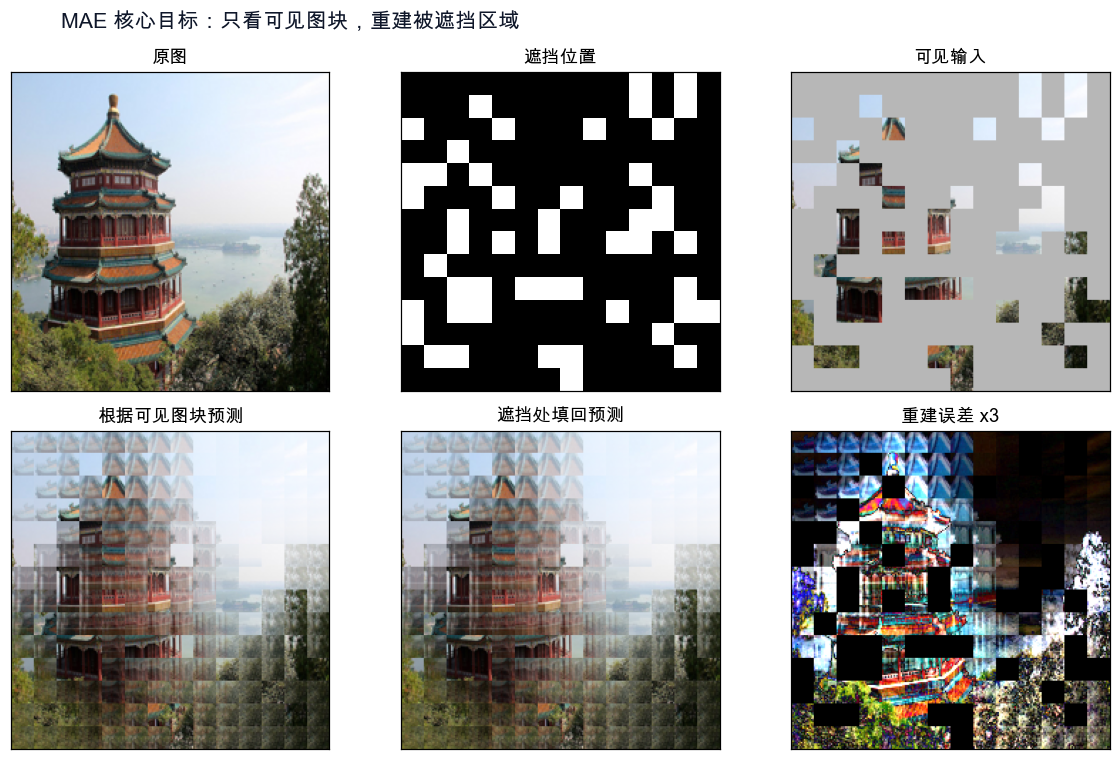

In [4]:
# 绘制可见输入、预测图块和重建图像。
fig, axes = plt.subplots(2, 3, figsize=(10.8, 7.0))
plot_items = [
    (mae_image, "原图", None),
    (mae_mask_map, "遮挡位置", "Greys"),
    (mae_masked_image, "可见输入", None),
    (pred_image, "根据可见图块预测", None),
    (mae_reconstruction, "遮挡处填回预测", None),
    (np.abs(mae_image - mae_reconstruction) * 3, "重建误差 x3", None),
]
for ax, (data, title, cmap) in zip(axes.ravel(), plot_items):
    ax.imshow(np.clip(data, 0, 1), cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("MAE 核心目标：只看可见图块，重建被遮挡区域", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()